In [1]:
import yfinance as yf
import pandas as pd

tickers = ['CBA.AX', 'BHP.AX', 'CSL.AX', 'WES.AX', 'WOW.AX', 'VAS.AX']

data = yf.download(tickers, start='2023-01-01', end='2026-10-01')

print(data.shape)
data.head()

[*********************100%***********************]  6 of 6 completed

(949, 30)


Price           Close                                                          \
Ticker         BHP.AX     CBA.AX      CSL.AX     VAS.AX     WES.AX     WOW.AX   
Date                                                                            
2023-01-03  37.381813  87.825127  262.253754  75.404320  40.386509  29.246292   
2023-01-04  37.967316  89.641586  264.348083  76.608047  41.248260  29.334675   
2023-01-05  37.975559  89.798035  261.099579  76.722252  41.328213  29.378870   
2023-01-06  39.179562  89.676346  259.023895  77.205528  41.763531  29.361191   
2023-01-09  39.583645  89.798035  257.832428  77.671204  42.047821  29.785437   

Price            High                                    ...        Open  \
Ticker         BHP.AX     CBA.AX      CSL.AX     VAS.AX  ...      CSL.AX   
Date                                                     ...               
2023-01-03  38.016798  90.302133  268.276050  77.012221  ...  267.885101   
2023-01-04  38.082767  89.771956  264.915860  76.616829  ...  262.598169   
2023-01-05  38.132247  90.997425  265.269558  77.126422  ...  264.692465   
2023-01-06  39.402220  90.015304  260.029150  77.293390  ...  258.809800   
2023-01-09  39.938249  90.636744  259.433410  78.066586  ...  258.111658   

Price                                         Volume                   \
Ticker         VAS.AX     WES.AX     WOW.AX   BHP.AX   CBA.AX  CSL.AX   
Date                                                                    
2023-01-03  77.012221  40.884012  29.705890  4480991  1709983  493499   
2023-01-04  75.905138  40.955088  29.555635  7802250  2276220  694196   
2023-01-05  76.880406  41.514775  29.387707  7536105  1693577  707606   
2023-01-06  76.783781  41.745766  29.281645  8106986  2450188  919963   
2023-01-09  77.811781  42.030053  29.608668  5757435  1048736  718650   

Price                                   
Ticker        VAS.AX   WES.AX   WOW.AX  
Date                                    
2023-01-03  310891.0   978612  1134546  
2023-01-04  113157.0  1445421  1634732  
2023-01-05  138744.0  1440451  1389352  
2023-01-06  162973.0  1129379   926235  
2023-01-09  203066.0   610545  1024964  

[5 rows x 30 columns]

In [21]:
def get_latest_prices(tickers):
    data = yf.download(tickers, period="5d", interval="1m", progress=False)["Close"]
    return data.ffill().iloc[-1]

latest = get_latest_prices(tickers)
print(latest)

Ticker
BHP.AX     61.209999
CBA.AX    151.449997
CSL.AX    175.350006
VAS.AX    107.519997
WES.AX     76.220001
WOW.AX     38.349998
Name: 2026-10-02 16:11:00+10:00, dtype: float64


In [2]:
close_prices = data['Close']
close_prices.head()

Ticker,BHP.AX,CBA.AX,CSL.AX,VAS.AX,WES.AX,WOW.AX
Date,,,,,,
2023-01-03,37.381813,87.825127,262.253754,75.404320,40.386509,29.246292
2023-01-04,37.967316,89.641586,264.348083,76.608047,41.248260,29.334675
2023-01-05,37.975559,89.798035,261.099579,76.722252,41.328213,29.378870
2023-01-06,39.179562,89.676346,259.023895,77.205528,41.763531,29.361191
2023-01-09,39.583645,89.798035,257.832428,77.671204,42.047821,29.785437


In [3]:
daily_returns = close_prices.pct_change().dropna()
daily_returns.head()

Ticker,BHP.AX,CBA.AX,CSL.AX,VAS.AX,WES.AX,WOW.AX
Date,,,,,,
2023-01-04,0.015663,0.020683,0.007986,0.015964,0.021338,0.003022
2023-01-05,0.000217,0.001745,-0.012289,0.001491,0.001938,0.001507
2023-01-06,0.031705,-0.001355,-0.007950,0.006299,0.010533,-0.000602
2023-01-09,0.010314,0.001357,-0.004600,0.006032,0.006807,0.014449
2023-01-10,-0.004167,0.000000,-0.004946,-0.002941,-0.007606,-0.002077


In [4]:
daily_volatility = daily_returns.std()
annualized_volatility = daily_volatility * (252 ** 0.5)
annualized_volatility.sort_values(ascending=False)

Ticker
CSL.AX    0.279267
BHP.AX    0.240782
CBA.AX    0.201809
WOW.AX    0.195667
WES.AX    0.189163
VAS.AX    0.118139
dtype: float64

In [5]:
correlation_matrix = daily_returns.corr()
correlation_matrix

Ticker,BHP.AX,CBA.AX,CSL.AX,VAS.AX,WES.AX,WOW.AX
Ticker,,,,,,
BHP.AX,1.000000,0.116998,0.054239,0.612382,0.156697,0.081759
CBA.AX,0.116998,1.000000,0.125684,0.613959,0.397537,0.194980
CSL.AX,0.054239,0.125684,1.000000,0.319399,0.164596,0.128855
VAS.AX,0.612382,0.613959,0.319399,1.000000,0.562875,0.269057
WES.AX,0.156697,0.397537,0.164596,0.562875,1.000000,0.272559
WOW.AX,0.081759,0.194980,0.128855,0.269057,0.272559,1.000000


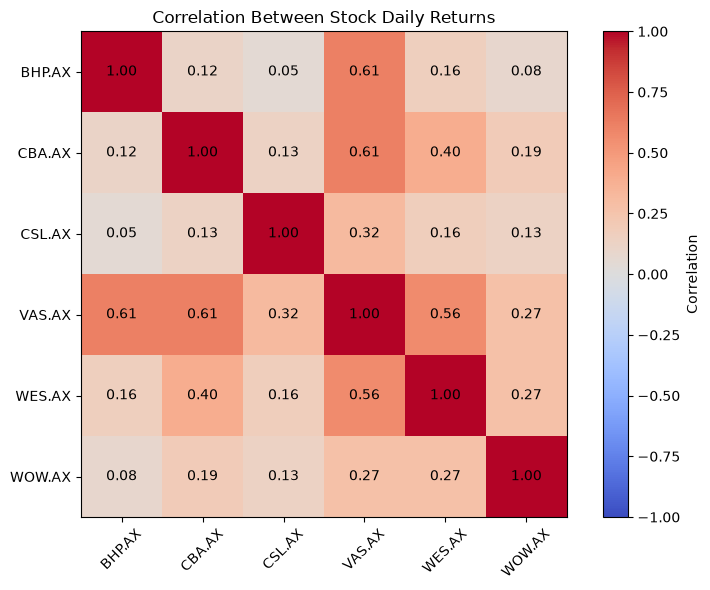

In [6]:
import matplotlib.pyplot as plt

plt.figure(figsize=(8,6))
plt.imshow(correlation_matrix, cmap='coolwarm', vmin=-1, vmax=1)
plt.colorbar(label='Correlation')
plt.xticks(range(len(correlation_matrix.columns)), correlation_matrix.columns, rotation=45)
plt.yticks(range(len(correlation_matrix.columns)), correlation_matrix.columns)
plt.title('Correlation Between Stock Daily Returns')

for i in range(len(correlation_matrix)):
    for j in range(len(correlation_matrix)):
        plt.text(j, i, f'{correlation_matrix.iloc[i,j]:.2f}', 
                  ha='center', va='center', color='black')

plt.tight_layout()
plt.savefig('../data/correlation_heatmap.png', dpi=150, bbox_inches='tight')
plt.show()


In [7]:
annual_returns = daily_returns.mean() * 252
risk_free_rate = 0.04
sharpe_ratios = (annual_returns - risk_free_rate) / annualized_volatility
sharpe_ratios.sort_values(ascending=False)

Ticker
WES.AX    0.789949
CBA.AX    0.619079
VAS.AX    0.543583
BHP.AX    0.479266
WOW.AX    0.293198
CSL.AX   -0.310011
dtype: float64

In [ ]:
import numpy as np

num_portfolios = 10000
num_assets = len(tickers)

# Arrays to store results
results = np.zeros((3, num_portfolios))  # row 0: return, row 1: risk, row 2: sharpe
weights_record = []

mean_returns = daily_returns.mean() * 252
cov_matrix = daily_returns.cov() * 252  # annualized covariance matrix

for i in range(num_portfolios):
    # Generate random weights that sum to 1
    weights = np.random.random(num_assets)
    weights /= np.sum(weights)
    weights_record.append(weights)

    # Portfolio return = weighted sum of individual returns
    portfolio_return = np.sum(weights * mean_returns)

    # Portfolio risk = accounts for how assets move together (covariance), not just individual volatility
    portfolio_risk = np.sqrt(np.dot(weights.T, np.dot(cov_matrix, weights)))

    # Portfolio Sharpe ratio
    portfolio_sharpe = (portfolio_return - risk_free_rate) / portfolio_risk

    results[0, i] = portfolio_return
    results[1, i] = portfolio_risk
    results[2, i] = portfolio_sharpe

print("Simulation complete")
print(results[:, :5])  

Simulation complete
[[0.08684415 0.1174853  0.0946009  0.10432283 0.15261084]
 [0.12937691 0.12564131 0.12589397 0.13610838 0.15156434]
 [0.36207501 0.61671834 0.43370543 0.47258535 0.74299035]]


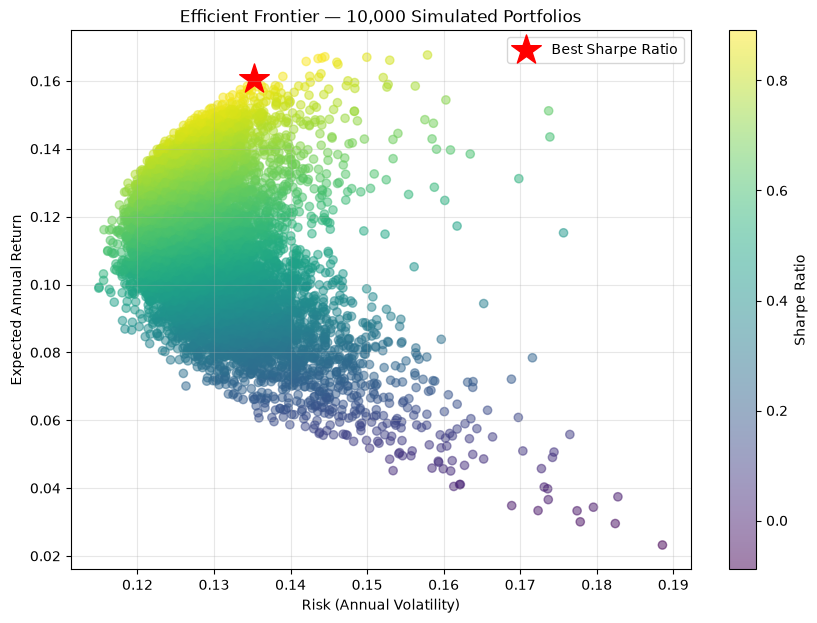

In [14]:
plt.figure(figsize=(10,7))

scatter = plt.scatter(results[1,:], results[0,:], c=results[2,:], cmap='viridis', alpha=0.5)
plt.colorbar(scatter, label='Sharpe Ratio')

max_sharpe_idx = np.argmax(results[2,:])
plt.scatter(results[1, max_sharpe_idx], results[0, max_sharpe_idx], 
            color='red', marker='*', s=500, label='Best Sharpe Ratio')

plt.xlabel('Risk (Annual Volatility)')
plt.ylabel('Expected Annual Return')
plt.title('Efficient Frontier — 10,000 Simulated Portfolios')
plt.legend()
plt.grid(alpha=0.3)
plt.savefig('../data/efficient_frontier.png', dpi=150, bbox_inches='tight')
plt.show()

In [10]:
best_weights = weights_record[max_sharpe_idx]

best_portfolio = pd.DataFrame({
    'Ticker': tickers,
    'Weight': best_weights
}).sort_values('Weight', ascending=False)

best_portfolio['Weight'] = (best_portfolio['Weight'] * 100).round(2)
best_portfolio


,Ticker,Weight
4,WOW.AX,40.20
1,BHP.AX,34.41
0,CBA.AX,12.91
5,VAS.AX,11.03
2,CSL.AX,0.72
3,WES.AX,0.72


In [11]:
tickers=list(daily_returns.columns)
print(tickers)

['BHP.AX', 'CBA.AX', 'CSL.AX', 'VAS.AX', 'WES.AX', 'WOW.AX']


In [12]:
num_portfolios = 10000
num_assets = len(tickers)

results = np.zeros((3, num_portfolios))
weights_record = []

mean_returns = daily_returns.mean() * 252
cov_matrix = daily_returns.cov() * 252

for i in range(num_portfolios):
    weights = np.random.random(num_assets)
    weights /= np.sum(weights)
    weights_record.append(weights)

    portfolio_return = np.sum(weights * mean_returns)
    portfolio_risk = np.sqrt(np.dot(weights.T, np.dot(cov_matrix, weights)))
    portfolio_sharpe = (portfolio_return - risk_free_rate) / portfolio_risk

    results[0, i] = portfolio_return
    results[1, i] = portfolio_risk
    results[2, i] = portfolio_sharpe

print("Simulation complete")

Simulation complete


In [13]:
max_sharpe_idx = np.argmax(results[2,:])
best_weights = weights_record[max_sharpe_idx]

best_portfolio = pd.DataFrame({
    'Ticker': tickers,
    'Weight': best_weights
}).sort_values('Weight', ascending=False)

best_portfolio['Weight'] = (best_portfolio['Weight'] * 100).round(2)
best_portfolio

,Ticker,Weight
4,WES.AX,45.91
0,BHP.AX,18.92
1,CBA.AX,16.64
5,WOW.AX,14.67
3,VAS.AX,2.80
2,CSL.AX,1.06


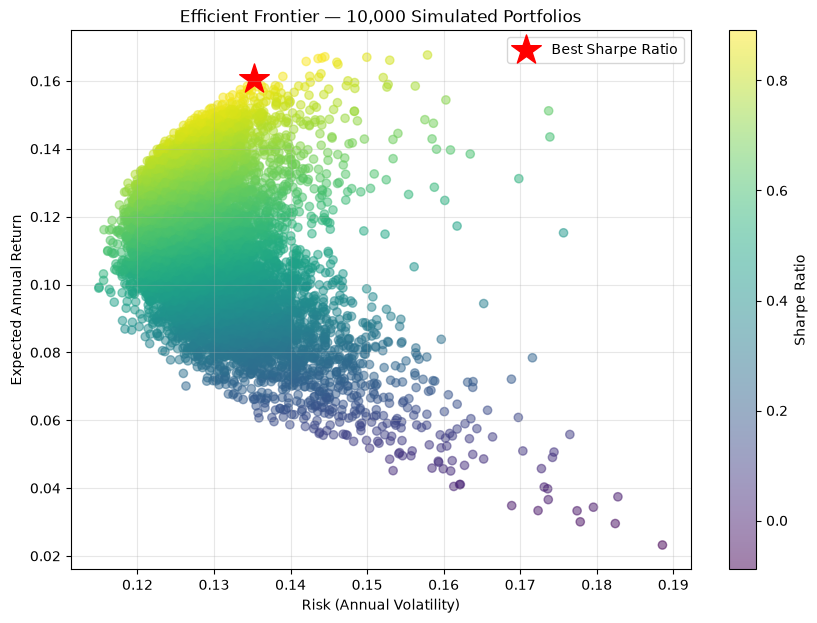

In [15]:
plt.figure(figsize=(10,7))

scatter = plt.scatter(results[1,:], results[0,:], c=results[2,:], cmap='viridis', alpha=0.5)
plt.colorbar(scatter, label='Sharpe Ratio')

max_sharpe_idx = np.argmax(results[2,:])
plt.scatter(results[1, max_sharpe_idx], results[0, max_sharpe_idx], 
            color='red', marker='*', s=500, label='Best Sharpe Ratio')

plt.xlabel('Risk (Annual Volatility)')
plt.ylabel('Expected Annual Return')
plt.title('Efficient Frontier — 10,000 Simulated Portfolios')
plt.legend()
plt.grid(alpha=0.3)
plt.savefig('../data/efficient_frontier.png', dpi=150, bbox_inches='tight')
plt.show()

In [16]:
portfolio_return = results[0, max_sharpe_idx]
portfolio_risk = results[1, max_sharpe_idx]

num_simulations = 1000
num_days = 252 

# Convert annual return/risk back to daily, since we're simulating day by day
daily_mean = portfolio_return / 252
daily_std = portfolio_risk / np.sqrt(252)

initial_investment = 10000  

simulation_results = np.zeros((num_days, num_simulations))

for sim in range(num_simulations):
    daily_sim_returns = np.random.normal(daily_mean, daily_std, num_days)
    price_path = initial_investment * np.cumprod(1 + daily_sim_returns)
    simulation_results[:, sim] = price_path

print("Monte Carlo simulation complete")
print(simulation_results[:5, :5]) 

Monte Carlo simulation complete
[[10008.31832817 10134.87276936  9978.45879802 10065.1364279
   9826.58631749]
 [10080.38453799 10140.99939239  9997.58523511 10242.395769
   9840.35652622]
 [10176.96599858 10161.67982326  9943.13922771 10440.95812354
   9967.90149237]
 [10186.25290807 10209.71333616  9998.51292678 10413.08598988
   9973.6904494 ]
 [10327.60881421 10364.86496825  9992.83968091 10575.74006175
  10065.81020815]]


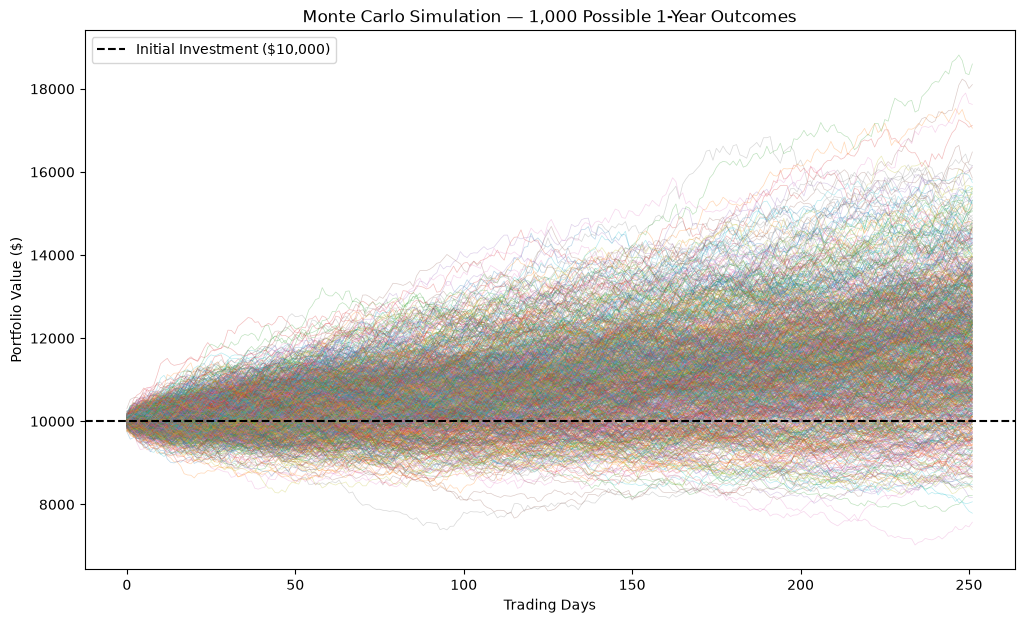

In [17]:
plt.figure(figsize=(12,7))
plt.plot(simulation_results, linewidth=0.5, alpha=0.3)
plt.axhline(y=initial_investment, color='black', linestyle='--', label='Initial Investment ($10,000)')
plt.xlabel('Trading Days')
plt.ylabel('Portfolio Value ($)')
plt.title('Monte Carlo Simulation — 1,000 Possible 1-Year Outcomes')
plt.legend()
plt.savefig('../data/monte_carlo_simulation.png', dpi=150, bbox_inches='tight')
plt.show()


In [18]:
final_values = simulation_results[-1, :]  # the last day of every simulation = ending value after 1 year

percentiles = {
    '5th percentile (worst-case-ish)': np.percentile(final_values, 5),
    '25th percentile': np.percentile(final_values, 25),
    '50th percentile (median)': np.percentile(final_values, 50),
    '75th percentile': np.percentile(final_values, 75),
    '95th percentile (best-case-ish)': np.percentile(final_values, 95),
}

for label, value in percentiles.items():
    print(f"{label}: ${value:,.2f}")

5th percentile (worst-case-ish): $9,372.80
25th percentile: $10,659.52
50th percentile (median): $11,750.83
75th percentile: $12,836.95
95th percentile (best-case-ish): $14,589.31


Based on this portfolio's historical behavior, there's a 90% chance that $10,000 invested today would be worth somewhere between $9,373 and $14,589 one year from now — with a median expected outcome around $11,751

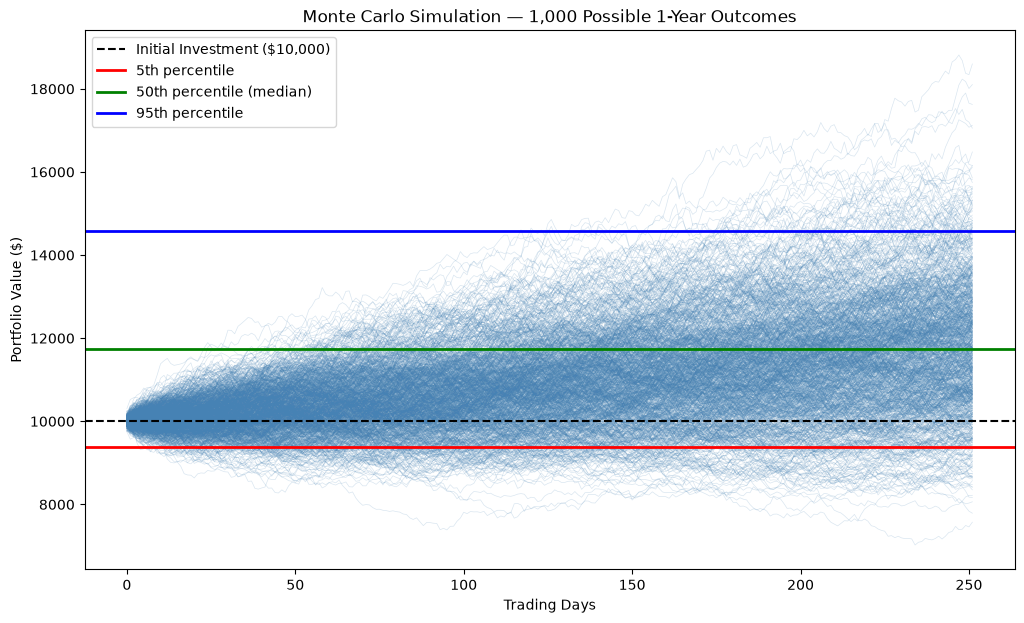

In [19]:
plt.figure(figsize=(12,7))
plt.plot(simulation_results, linewidth=0.5, alpha=0.2, color='steelblue')

# Horizontal lines for key percentiles
plt.axhline(y=initial_investment, color='black', linestyle='--', label='Initial Investment ($10,000)')
plt.axhline(y=percentiles['5th percentile (worst-case-ish)'], color='red', linestyle='-', linewidth=2, label='5th percentile')
plt.axhline(y=percentiles['50th percentile (median)'], color='green', linestyle='-', linewidth=2, label='50th percentile (median)')
plt.axhline(y=percentiles['95th percentile (best-case-ish)'], color='blue', linestyle='-', linewidth=2, label='95th percentile')

plt.xlabel('Trading Days')
plt.ylabel('Portfolio Value ($)')
plt.title('Monte Carlo Simulation — 1,000 Possible 1-Year Outcomes')
plt.legend()
plt.savefig('../data/monte_carlo_simulation1.png', dpi=150, bbox_inches='tight')
plt.show()